# Optimisation

In [2]:
import sys
sys.path.append("../..")
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
# %matplotlib inline
import pprint
pp = pprint.PrettyPrinter(indent=4)

ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


100%|██████████| 50/50 [04:05<00:00,  4.91s/it]


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


...

ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


ERROR:: Parameter set leads to degenerate geometry.
ERROR:: Parameter set leads to degenerate geometry.


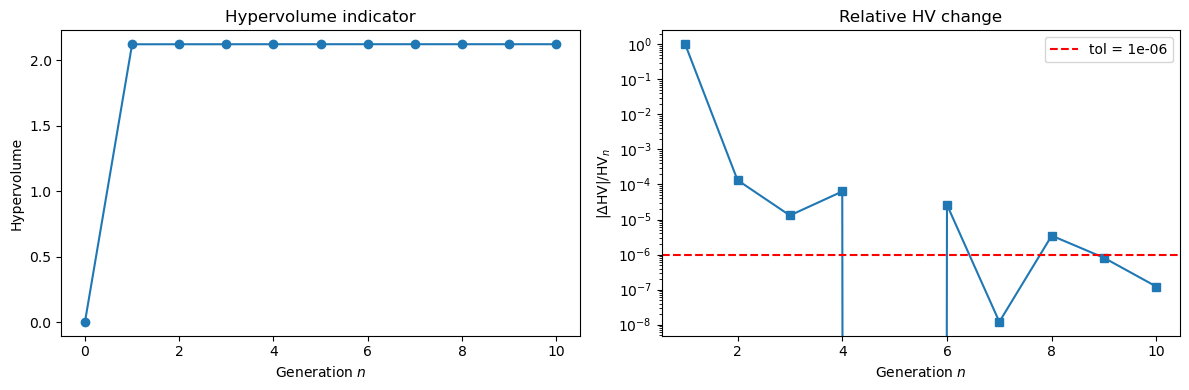

In [8]:
cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations', 
    overwrite=True
)
cell_type = 'mid-cell'

tune_config = {
        'freqs': 801.58,
        'cell_type': {cell_type: 'Req'},
        'processes': 4,
        'eigenmode_config': {'n_cells': 1,
                             'n_modules': 1,
                             'f_shift': 0,
                             'bc': 33,
                             'beampipes': 'both',
                            },
    }
wakefield_config = {'n_cells': 1, 'n_modules': 1,
                         'MROT': 2, 'MT': 4, 'NFS': 10000, 'UBT': 50, 'bunch_length': 25,
                         'DDR_SIG': 0.1, 'DDZ_SIG': 0.1,
                         'WG_M': None, 'marker': ''
                        }

optimisation_config = {
    'initial_points': 15,
    'method': {
        'LHS': {'seed': 5},
        # 'Sobol Sequence': {'index': 2},
        # 'Random': {},
        # 'Uniform': {},
        },
    # 'mid-cell': [1, 2, 3, 3, 6, 5, 2],  # must enter if end-cell selected
    'tune_config': tune_config,
    'wakefield_config': wakefield_config,
    'optimisation by': 'pareto',
    'crossover_factor': 5,
    'elites_for_crossover': 2,
    'mutation_factor': 5,
    'chaos_factor': 5,
    'processes': 3,
    'no_of_generation': 50,
    'bounds': {'A': [20.0, 80.0],
               'B': [20.0, 80.0],
               'a': [10.0, 60.0],
               'b': [10., 60.0],
               'Ri': [60.0, 85.0],
               'L': [93.5, 93.5],
               'Req': [170.0, 170.0]},
    'objectives': [
        # ['equal', 'freq [MHz]', 801.58],
                      ['min', 'Epk/Eacc []'],
                      ['min', 'Bpk/Eacc [mT/MV/m]'],
                      # ['min', 'ZL', [1, 2, 5]],
                      # ['min', 'ZT', [1, 2, 5]],
                  ],
    'weights': [1, 1], #, 1, 1, 1, 1]
    'hv_tol': 1e-6,
    'hv_consecutive': 2
}
cavs.run_optimisation(optimisation_config)

(<Figure size 400x400 with 1 Axes>,
 array([[<Axes: xlabel='Epk/Eacc []', ylabel='Bpk/Eacc [mT/MV/m]'>]],
       dtype=object))

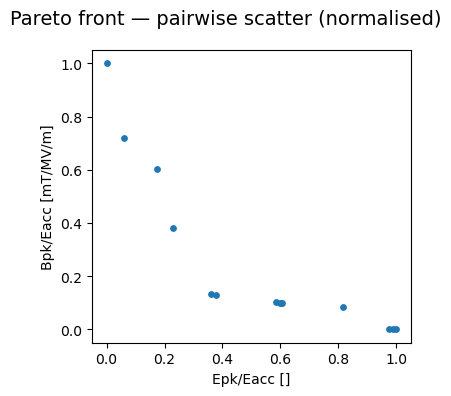

In [3]:
cavs.optimisation.plot_pareto(kind='scatter', marker='o', alpha=1)

(<Figure size 400x400 with 1 Axes>,
 array([[<Axes: xlabel='Epk/Eacc []', ylabel='Bpk/Eacc [mT/MV/m]'>]],
       dtype=object))

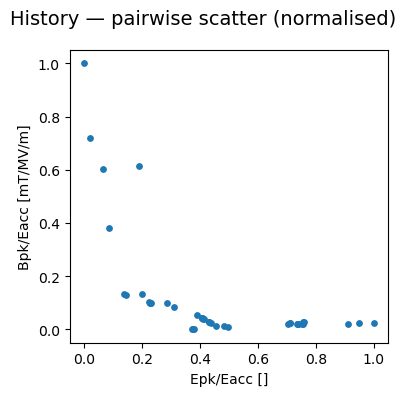

In [4]:
cavs.optimisation.plot_history(kind='scatter', color_by_gen=True, marker='o', alpha=1)

c:\Users\Soske\Documents\git_projects\cavsim2d\docs\notebooks\../..\cavsim2d\solvers\solver_objects.py:742: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 500x400 with 2 Axes>,
 {'Epk/Eacc [] vs Bpk/Eacc [mT/MV/m]': <Axes: label='Epk/Eacc [] vs Bpk/Eacc [mT/MV/m]', xlabel='Epk/Eacc []', ylabel='Bpk/Eacc [mT/MV/m]'>})

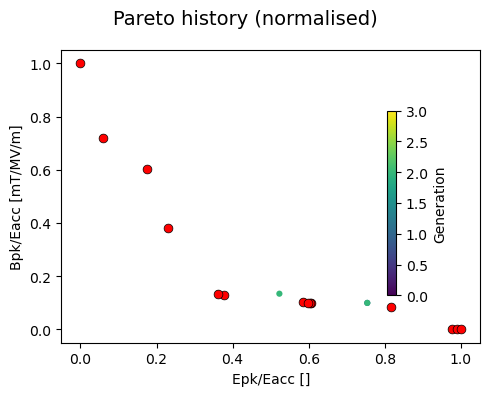

In [5]:
cavs.optimisation.plot_pareto_history(color_by_gen=True, marker='o', alpha=1)

# Optimisation with UQ

In [1]:
import sys
sys.path.append("..")
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
# %matplotlib inline
import pprint
pp = pprint.PrettyPrinter(indent=4)

In [2]:
cavs = Cavities([])
# must first save cavities
cavs.save(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')
cell_type = 'mid-cell'

optimisation_config = {
    'initial_points': 50,
    'method': {
        'LHS': {'seed': 6},
        # 'Sobol Sequence': {'index': 2},
        # 'Random': {},
        # 'Uniform': {},
        },
    # 'mid-cell': [1, 2, 3, 3, 6, 5, 2],  # must enter if end-cell selected
    'tune_config': {
        'freqs': 801.58,
        'cell_type': {cell_type: 'Req'},
        'processes': 4,
        'eigenmode_config': {'n_cells': 1,
                             'n_modules': 1,
                             'f_shift': 0,
                             'bc': 33,
                             'beampipes': 'both',
                             'uq_config': {
                                 'variables': ['A'],
                                 'objectives': ["Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
                                 'delta': [0.05],
                                 'processes': 4,
                                 'distribution': 'gaussian',
                                 'method': ['Stroud3'], 
                                 'cell_type': 'mid-cell',
                                 'cell complexity': 'simplecell'
                                }
                            },
    },
    'wakefield_config': {'n_cells': 1, 
                         'n_modules': 1,
                         'MROT': 2, 
                         'MT': 4, 
                         'NFS': 10000, 
                         'UBT': 50, 
                         'beam_config': {
                             'bunch_length': 25
                         },
                        'wake_config': {
                            'wakelength': 50
                        },
                         'DDR_SIG': 0.1, 
                         'DDZ_SIG': 0.1,
                         'WG_M': None, 
                         'marker': '',
                         'uq_config': {
                             'variables': ['A'],
                             'objectives': [["ZL", [1, 2, 5]], ["ZT", [2, 3, 4]]],
                             'delta': [0.05],
                             'processes': 4,
                             'distribution': 'gaussian',
                             'method': ['Stroud3'],
                             'cell_type': 'mid-cell',
                             'cell complexity': 'simplecell'
                             }
                        },
    'optimisation by': 'pareto',
    'crossover_factor': 5,
    'elites_for_crossover': 2,
    'mutation_factor': 5,
    'chaos_factor': 5,
    'processes': 3,
    'no_of_generation': 2,
    'bounds': {'A': [20.0, 80.0],
               'B': [20.0, 80.0],
               'a': [10.0, 60.0],
               'b': [10., 60.0],
               'Ri': [60.0, 85.0],
               'L': [93.5, 93.5],
               'Req': [170.0, 170.0]},
    'objectives': [
        # ['equal', 'freq [MHz]', 801.58],
                      ['min', 'Epk/Eacc []'],
                      ['min', 'Bpk/Eacc [mT/MV/m]'],
                      ['min', 'ZL', [1, 2, 5]],
                      ['min', 'ZT', [1, 2, 5]],
                  ],
    'weights': [1, 1, 1, 1, 1, 1]
}
cavs.run_optimisation(optimisation_config)

  0%|          | 0/2 [00:00<?, ?it/s]

ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: UQ wakefield: 6 of 6 perturbed cavities failed to produce ABCI impedance output; skipping uq.json for G0_C0_P.
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: UQ wakefield: 6 of 6 perturbed cavities failed to produce ABCI impedance output; skipping uq.json for G0_C1_P.
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: UQ wakefield: 6 of 6 perturbed cavities failed to produce ABCI impedance output; skipping uq.json for G0_C3_P.
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR:: skipped, yp_dip = []
ERROR

AssertionError: None